In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import files
import zipfile
import os


# Create dataset folder if not exists
DATASET_DIR = "dataset"
if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR)

print("Please upload your zipped dataset folder:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')

    if fn.endswith(".zip"):
        zip_path = fn

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(DATASET_DIR)

        print(f"Successfully extracted {fn} to '{DATASET_DIR}/'")

        # Optional: remove zip after extraction
        os.remove(zip_path)
    else:
        print(f"Skipping non-zip file: {fn}")

print(" Dataset upload and extraction complete.")


Please upload your zipped dataset folder:


Saving 5. Movie Review Dataset.zip to 5. Movie Review Dataset.zip
User uploaded file "5. Movie Review Dataset.zip"
Successfully extracted 5. Movie Review Dataset.zip to 'dataset/'
 Dataset upload and extraction complete.


In [ ]:
!pip install gensim
!pip install contractions wordcloud gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.7 MB/s eta 0:00:00


Import libraries

In [ ]:
!pip install --upgrade jax jaxlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 8.7 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All imports successful.")

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.10.0, so it will not be used.
  warnings.warn(
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All imports successful.


Load the dataset

In [ ]:
import pandas as pd
import os

DATASET_DIR = "dataset"

# Find all CSV files in the extracted dataset folder
csv_files = []
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print(f"Found CSV files: {csv_files}")

# Load and combine all CSV files
df_list = []
for csv_file in csv_files:
    temp_df = pd.read_csv(csv_file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
print(f"Combined shape: {df.shape}")
print(df.head(3))

# Rename columns to standard names
df.rename(columns={'review': 'text', 'sentiment': 'label'}, inplace=True)

# Keep only text and label columns
df = df[['label', 'text']].dropna().reset_index(drop=True)

# Ensure balanced 50/50 sample (25k per class)
df_neg = df[df['label'] == 0].sample(25000, random_state=42)
df_pos = df[df['label'] == 1].sample(25000, random_state=42)
df = pd.concat([df_neg, df_pos]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Final shape : {df.shape}")
print("Label distribution:")
print(df['label'].value_counts())
df.head()

Found CSV files: ['dataset/5. Movie Review Dataset/test_movie_review.csv', 'dataset/5. Movie Review Dataset/train_movie_review.csv', 'dataset/5. Movie Review Dataset/val_movie_review.csv']
Combined shape: (50000, 3)
   Unnamed: 0                                             review  sentiment
0       33553  I really liked this Summerslam due to the look...          1
1        9427  Not many television shows appeal to quite as m...          1
2         199  The film quickly gets to a major chase scene w...          0
Final shape : (50000, 2)
Label distribution:
label
1    25000
0    25000
Name: count, dtype: int64


,label,text
0,1,Chris Rock stars in this remake of Warren Beat...
1,0,As I sit and think about Poison for the Fairie...
2,0,"Reading the other user comments, the review by..."
3,0,"""The 700 Club"" has to be the single most bigot..."
4,1,I picked this up in the 'Danger After Dark' bo...


Text pre processing and cleaning

In [ ]:
lemmatizer = WordNetLemmatizer()

# Keep negation words — critical for sentiment analysis
stop_words = set(stopwords.words('english'))
negation_words = {
    'no', 'not', 'nor', 'never', 'neither', 'nobody', 'nothing',
    'nowhere', 'hardly', 'barely', 'scarcely'
}
stop_words = stop_words - negation_words

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # 3. Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)
    # 4. Remove hashtags (#)
    text = re.sub(r'#\w+', '', text)
    # 5. Handle contractions BEFORE removing special characters
    #    e.g. "don't" -> "do not"  (preserves "not")
    text = contractions.fix(text)
    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 7. Remove special characters — keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 9. Remove stopwords (negations kept) and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

# Show before/after examples
for i in range(3):
    print(f"Original : {df['text'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned_text'].iloc[i]}")
    print()

Original : Chris Rock stars in this remake of Warren Beatty's Heaven Can Wait (itself a remake of the 1941 film Here Comes Mr. Jordan), a comedy about a man who dies before his time, before he can realize his dreams, and his adventures in his new (albeit temporary) body. In the Beatty version, the protagonist was a backup quarterback for the then-Los Angeles Rams. In Rock's hipper version, our lead character is a struggling young - and decidedly low-talent - standup comedian.<br /><br />It's very funny to see the razor-sharp Rock playing a bad comedian. It's kind of like seeing Tom Hanks play a bad actor. Lance Barton's dream is to play the legendary Apollo Theater on a non-amateur night. But every time he tries out his material, he's booed off the stage lustily - so much so that his nickname becomes "Booie." His jokes are lame, his delivery painful. In short, Lance is everything that the real Chris Rock isn't.<br /><br />Lance is also a bike messenger, and he's riding the streets on h

Visualization

1. Word cloud

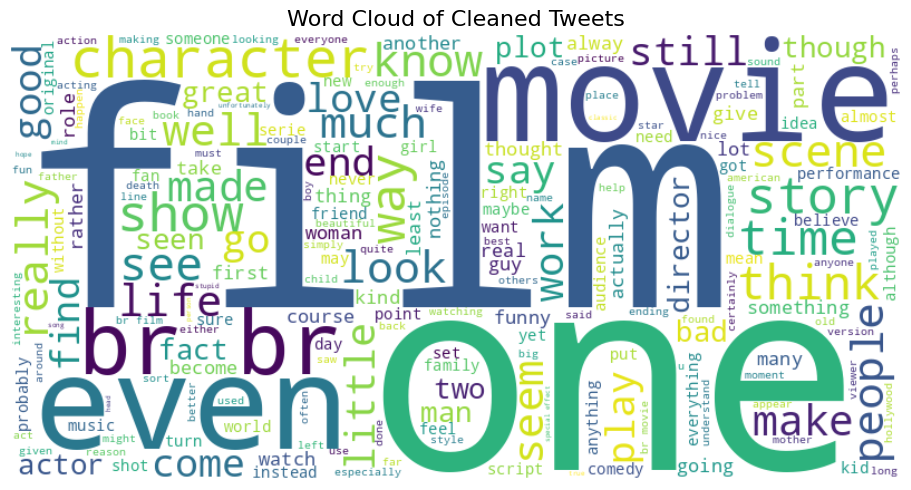

In [ ]:
all_words = ' '.join(df['cleaned_text'].dropna())

wc = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(all_words)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Tweets', fontsize=16)
plt.tight_layout()
plt.show()

2. Top 20 most frequent words

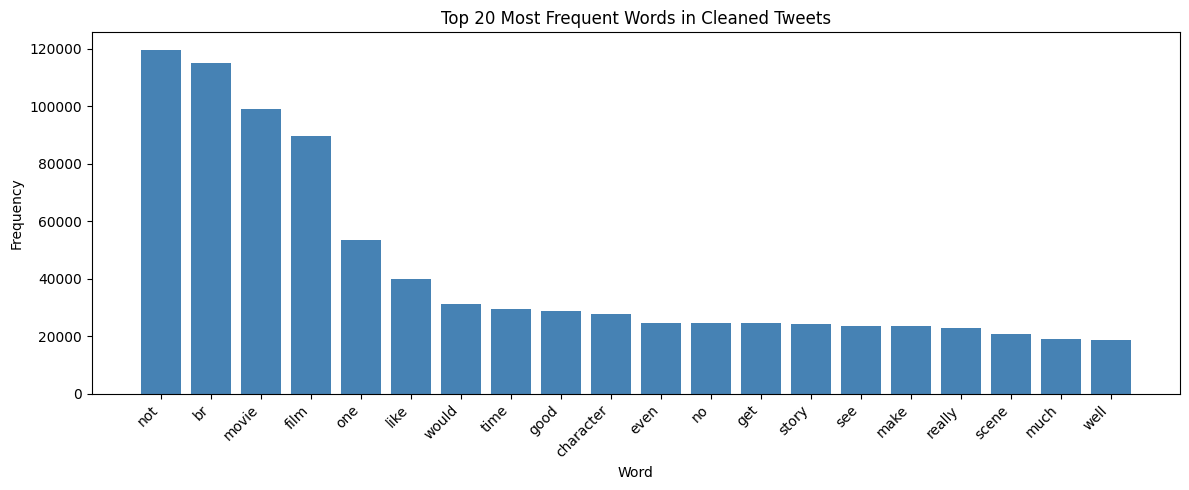

In [ ]:
word_freq = Counter(all_words.split())
top_20 = word_freq.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words in Cleaned Tweets')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Train - test split

In [ ]:
X = df['cleaned_text'].values
y = df['label'].values

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 40000 | Test size: 10000


Tokenization

In [ ]:
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # fit ONLY on training data

word_index = tokenizer.word_index
print(f"Vocabulary size (capped at {VOCAB_SIZE}): {len(word_index)} unique tokens found")

Vocabulary size (capped at 20000): 144541 unique tokens found


Sequence Padding (Percentile-Based)

In [ ]:
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding length to avoid excessively long sequences
lengths = [len(seq) for seq in train_sequences]
MAX_LEN = int(np.percentile(lengths, 95))  # 95th percentile
print(f"Using MAX_LEN = {MAX_LEN} (95th percentile of training sequence lengths)")

X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad  shape: {X_test_pad.shape}")

Using MAX_LEN = 318 (95th percentile of training sequence lengths)
X_train_pad shape: (40000, 318)
X_test_pad  shape: (10000, 318)


Model Building and Training

Model 1: Simple RNN with Trainable Embedding

---



In [ ]:
EMBEDDING_DIM = 64

import warnings
warnings.filterwarnings('ignore')

model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
model1.add(SimpleRNN(64))
model1.add(Dense(1, activation='sigmoid'))

model1.build(input_shape=(None, MAX_LEN))
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 318, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,321 (4.91 MB)

 Trainable params: 1,288,321 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

Model 2: LSTM with Trainable Embedding

In [ ]:
model2 = Sequential(name='LSTM_Trainable_Embedding')
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
model2.add(LSTM(64))
model2.add(Dense(1, activation='sigmoid'))

model2.build(input_shape=(None, MAX_LEN))
model2.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 318, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,089 (5.01 MB)

 Trainable params: 1,313,089 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

 Load Word2Vec Pretrained Embeddings

In [ ]:
import gensim.downloader as api

# Load pretrained Word2Vec embeddings (Google News, 300-dimensional)
embedding_model = api.load('word2vec-google-news-300')
print("Word2Vec model loaded successfully.")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec model loaded successfully.


Build Embedding Matrix

In [ ]:
WORD2VEC_DIM = 300  # Word2Vec Google News uses 300 dimensions

embedding_matrix = np.zeros((VOCAB_SIZE, WORD2VEC_DIM))

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
    # Words not found in Word2Vec remain as all-zero vectors

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (20000, 300)


Model 3: LSTM with word2vec Embedding

In [ ]:
model3 = Sequential(name='LSTM_Word2Vec_Embedding')
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=WORD2VEC_DIM,
    weights=[embedding_matrix],
    trainable=False  # freeze pretrained Word2Vec weights
))
model3.add(LSTM(64))
model3.add(Dense(1, activation='sigmoid'))

model3.build(input_shape=(None, MAX_LEN))
model3.summary()

Model: "LSTM_Word2Vec_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 318, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,093,505 (23.24 MB)

 Trainable params: 93,505 (365.25 KB)

 Non-trainable params: 6,000,000 (22.89 MB)

 Model Training and Evaluation

Compile All Models

In [ ]:
# Binary classification:
#   Loss     -> binary_crossentropy
#   Optimizer-> adam
#   Metric   -> accuracy

for model in [model1, model2, model3]:
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

print("All models compiled.")

All models compiled.


Train model 1

In [ ]:
EPOCHS = 30
BATCH  = 128

early_stop1 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("=== Training Model 1: Simple RNN ===")
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=0.1,
    callbacks=[early_stop1],
    verbose=1,

)

=== Training Model 1: Simple RNN ===
Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.4988 - loss: 0.6943 - val_accuracy: 0.4947 - val_loss: 0.6928
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.5226 - loss: 0.6846 - val_accuracy: 0.5000 - val_loss: 0.6968
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.5222 - loss: 0.6855 - val_accuracy: 0.4933 - val_loss: 0.6939
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.5229 - loss: 0.6903 - val_accuracy: 0.4922 - val_loss: 0.7001
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.5245 - loss: 0.6854 - val_accuracy: 0.5085 - val_loss: 0.6927
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5284 - loss: 0.6713 - val_accuracy: 0.4992 - val_loss: 0.6963
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.5311 - loss: 0.6641 - val_accuracy: 0.5113 - val_loss: 0.6964
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - 

Model 2 training

In [ ]:
early_stop2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("=== Training Model 2: LSTM (Trainable Embedding) ===")
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=0.1,
    callbacks=[early_stop2],
    verbose=1
)

=== Training Model 2: LSTM (Trainable Embedding) ===
Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.5198 - loss: 0.6743 - val_accuracy: 0.5085 - val_loss: 0.6975
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5279 - loss: 0.6589 - val_accuracy: 0.5105 - val_loss: 0.7129
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5325 - loss: 0.6548 - val_accuracy: 0.5128 - val_loss: 0.7140
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5331 - loss: 0.6549 - val_accuracy: 0.5100 - val_loss: 0.7426
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5339 - loss: 0.6508 - val_accuracy: 0.5130 - val_loss: 0.7333
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5467 - loss: 0.6468 - val_accuracy: 0.4935 - val_loss: 0.7476
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5477 - loss: 0.6418 - val_accuracy: 0.5117 - val_loss: 0.7762
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 14

Train model 3

In [ ]:
early_stop3 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("=== Training Model 3: LSTM (Word2vec Embedding) ===")
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_split=0.1,
    callbacks=[early_stop3],
    verbose=1
)

=== Training Model 3: LSTM (Word2vec Embedding) ===
Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5132 - loss: 0.6933 - val_accuracy: 0.6413 - val_loss: 0.6392
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5062 - loss: 0.6958 - val_accuracy: 0.5010 - val_loss: 0.6927
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5060 - loss: 0.6920 - val_accuracy: 0.5102 - val_loss: 0.6926
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5217 - loss: 0.6912 - val_accuracy: 0.5105 - val_loss: 0.6922
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5567 - loss: 0.6709 - val_accuracy: 0.7097 - val_loss: 0.6083
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5514 - loss: 0.6741 - val_accuracy: 0.5085 - val_loss: 0.6938
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5052 - loss: 0.6912 - val_accuracy: 0.5178 - val_loss: 0.6926
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22

Plot Training vs Validation (per model)

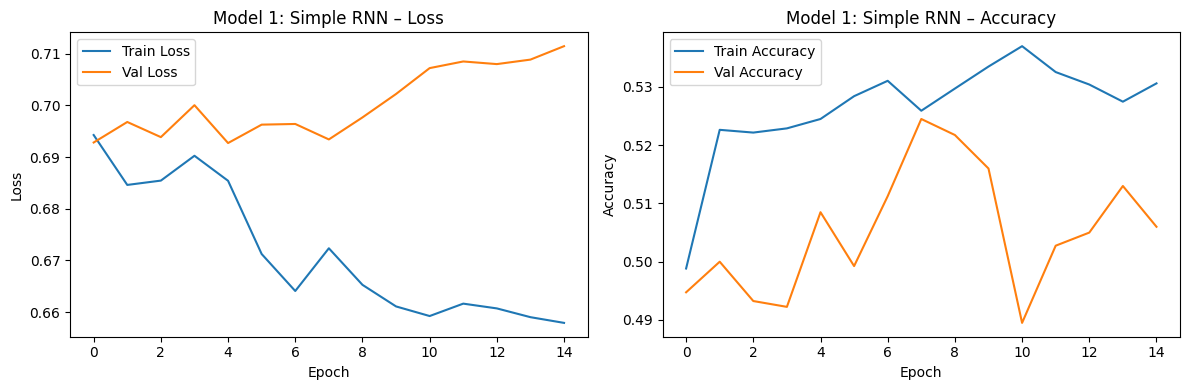

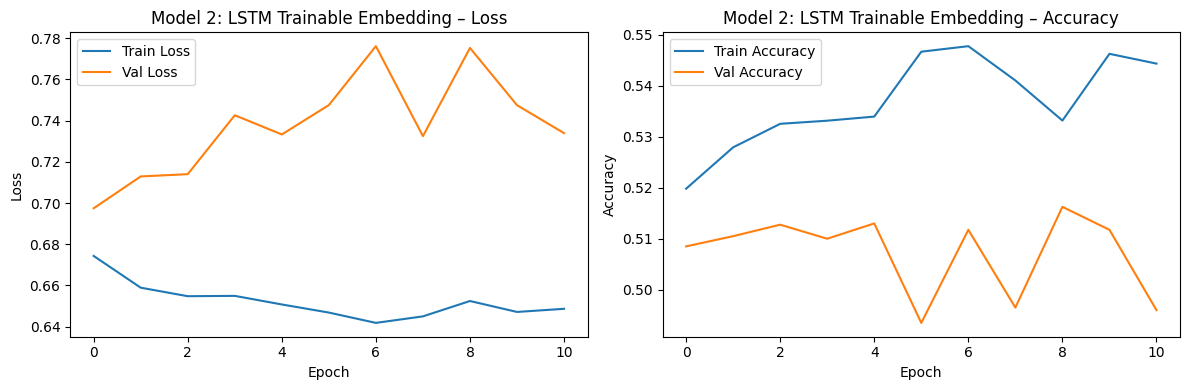

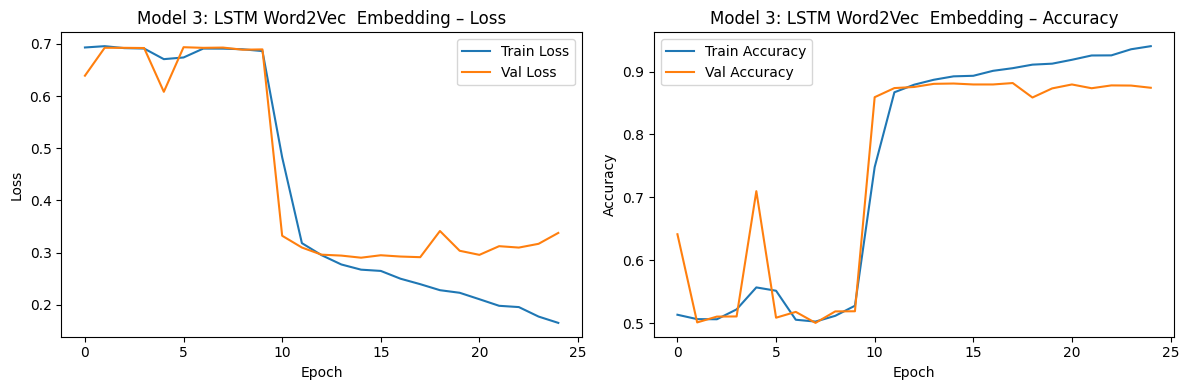

In [ ]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{model_name} – Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_title(f'{model_name} – Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history1, 'Model 1: Simple RNN')
plot_history(history2, 'Model 2: LSTM Trainable Embedding')
plot_history(history3, 'Model 3: LSTM Word2Vec  Embedding')

Compare All Three Models

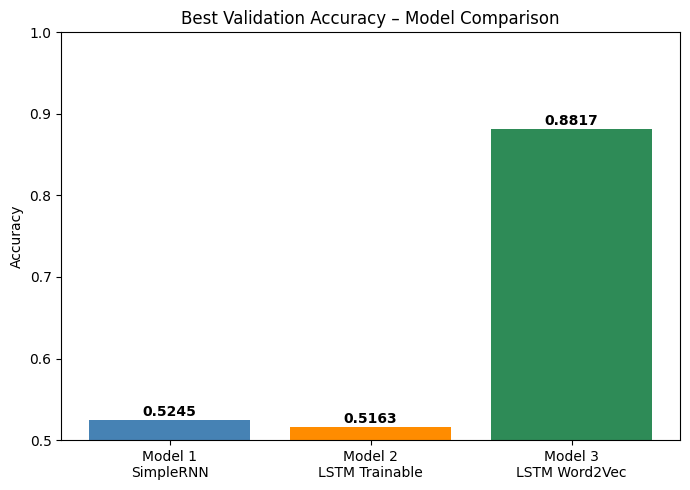

In [ ]:
model_names = ['Model 1\nSimpleRNN', 'Model 2\nLSTM Trainable', 'Model 3\nLSTM Word2Vec']
final_val_acc = [
    max(history1.history['val_accuracy']),
    max(history2.history['val_accuracy']),
    max(history3.history['val_accuracy'])
]

plt.figure(figsize=(7, 5))
plt.bar(model_names, final_val_acc, color=['steelblue', 'darkorange', 'seagreen'])
plt.ylim(0.5, 1.0)
plt.title('Best Validation Accuracy – Model Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(final_val_acc):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Evaluate All Models (Accuracy, Confusion Matrix, Classification Report)


===== Model 1: Simple RNN =====
Test Accuracy: 0.5034  |  Test Loss: 0.6941


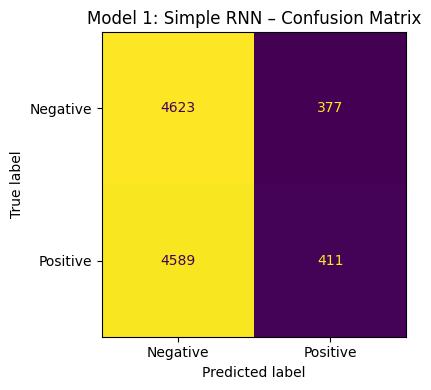

              precision    recall  f1-score   support

    Negative       0.50      0.92      0.65      5000
    Positive       0.52      0.08      0.14      5000

    accuracy                           0.50     10000
   macro avg       0.51      0.50      0.40     10000
weighted avg       0.51      0.50      0.40     10000


===== Model 2: LSTM Trainable =====
Test Accuracy: 0.5038  |  Test Loss: 0.7002


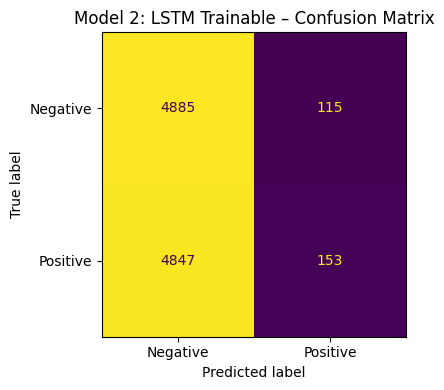

              precision    recall  f1-score   support

    Negative       0.50      0.98      0.66      5000
    Positive       0.57      0.03      0.06      5000

    accuracy                           0.50     10000
   macro avg       0.54      0.50      0.36     10000
weighted avg       0.54      0.50      0.36     10000


===== Model 3: LSTM Word2Vec =====
Test Accuracy: 0.8807  |  Test Loss: 0.2852


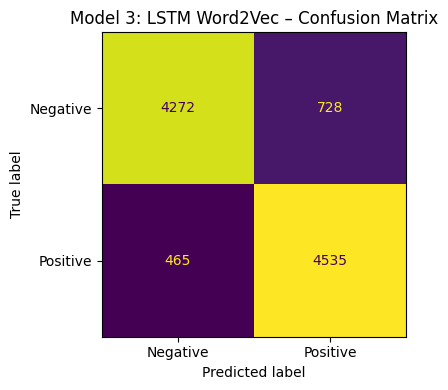

              precision    recall  f1-score   support

    Negative       0.90      0.85      0.88      5000
    Positive       0.86      0.91      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
def evaluate_model(model, X_test_pad, y_test, model_name):
    print(f'\n===== {model_name} =====')

    loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    print(f'Test Accuracy: {acc:.4f}  |  Test Loss: {loss:.4f}')

    y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} – Confusion Matrix')
    plt.tight_layout()
    plt.show()

    # Classification Report
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    return y_pred, y_pred_prob

y_pred1, y_prob1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1: Simple RNN')
y_pred2, y_prob2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2: LSTM Trainable')
y_pred3, y_prob3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3: LSTM Word2Vec')

Error Analysis

 Misclassified Examples

In [ ]:
# Using Model 2 as the reference for error analysis
misclassified_idx = np.where(y_pred2 != y_test)[0]

print(f"Total misclassified by Model 2: {len(misclassified_idx)} / {len(y_test)}")
print("\n--- 3 Misclassified Examples ---\n")

for i in misclassified_idx[:3]:
    print(f"Tweet (cleaned) : {X_test[i]}")
    print(f"True Label      : {'Positive' if y_test[i] == 1 else 'Negative'}")
    print(f"Predicted Label : {'Positive' if y_pred2[i] == 1 else 'Negative'}")
    print(f"Confidence      : {y_prob2[i]:.4f}")
    print()

Total misclassified by Model 2: 4997 / 10000

--- 3 Misclassified Examples ---

Tweet (cleaned) : wife watched movie plan visit sicily stromboli soon fortunately unfortunately landscape seascape complete tuna believable member cast expected reasonable wellwritten wellacted movie disappointed redeeming grace extended remarkable fishing sequence full authenticity thrashing tuna net wooden boat long oar passionate superstitious fishermenbr br movie sequencing stagy dialogue stilted acting range stiff completely overthetop one scene bergman stress macho native nave husband sics ferret innocent apparently already deceased rabbit would perfect grist monty python skitbr br volcano blew hoped merciful end suffering cast unfortunately movie continues flail staggering finally melodramatic absurd ending unless really oldtime tuna fishing pas hokey effort
True Label      : Negative
Predicted Label : Positive
Confidence      : 0.5145

Tweet (cleaned) : critique democratic administration well republ

Model Complexity vs Performance (Markdown cell)

In [ ]:
# ── Model Complexity vs Performance Evaluation ──────────────────────────────

# 1. Parameter counts — use built-in after training
t1  = model1.count_params()
t2  = model2.count_params()
t3  = model3.count_params()

nt1 = sum(tf.size(w).numpy() for w in model1.non_trainable_weights)
nt2 = sum(tf.size(w).numpy() for w in model2.non_trainable_weights)
nt3 = sum(tf.size(w).numpy() for w in model3.non_trainable_weights)

trainable1 = t1 - nt1
trainable2 = t2 - nt2
trainable3 = t3 - nt3

# 2. Test accuracy
loss1, acc1 = model1.evaluate(X_test_pad, y_test, verbose=0)
loss2, acc2 = model2.evaluate(X_test_pad, y_test, verbose=0)
loss3, acc3 = model3.evaluate(X_test_pad, y_test, verbose=0)

# 3. Epochs actually run
epochs_run1 = len(history1.history['loss'])
epochs_run2 = len(history2.history['loss'])
epochs_run3 = len(history3.history['loss'])

# 4. Summary DataFrame
complexity_df = pd.DataFrame({
    'Model': ['Model 1: SimpleRNN', 'Model 2: LSTM Trainable', 'Model 3: LSTM Word2Vec'],
    'Architecture': ['SimpleRNN', 'LSTM', 'LSTM'],
    'Embedding': ['Trainable', 'Trainable', 'Frozen '],
    'Trainable Params':     [trainable1, trainable2, trainable3],
    'Non-Trainable Params': [nt1, nt2, nt3],
    'Total Params':         [t1, t2, t3],
    'Epochs Run':           [epochs_run1, epochs_run2, epochs_run3],
    'Test Accuracy':        [round(acc1, 4), round(acc2, 4), round(acc3, 4)],
    'Test Loss':            [round(loss1, 4), round(loss2, 4), round(loss3, 4)]
})

print("=" * 70)
print("         MODEL COMPLEXITY vs PERFORMANCE SUMMARY")
print("=" * 70)
print(complexity_df.to_string(index=False))
print("=" * 70)

         MODEL COMPLEXITY vs PERFORMANCE SUMMARY
                  Model Architecture Embedding  Trainable Params  Non-Trainable Params  Total Params  Epochs Run  Test Accuracy  Test Loss
     Model 1: SimpleRNN    SimpleRNN Trainable           1288321                     0       1288321          15         0.5034     0.6941
Model 2: LSTM Trainable         LSTM Trainable           1313089                     0       1313089          12         0.5003     0.6939
 Model 3: LSTM Word2Vec         LSTM   Frozen              93505               6000000       6093505          25         0.8807     0.2852


 Visualize Complexity vs Performance

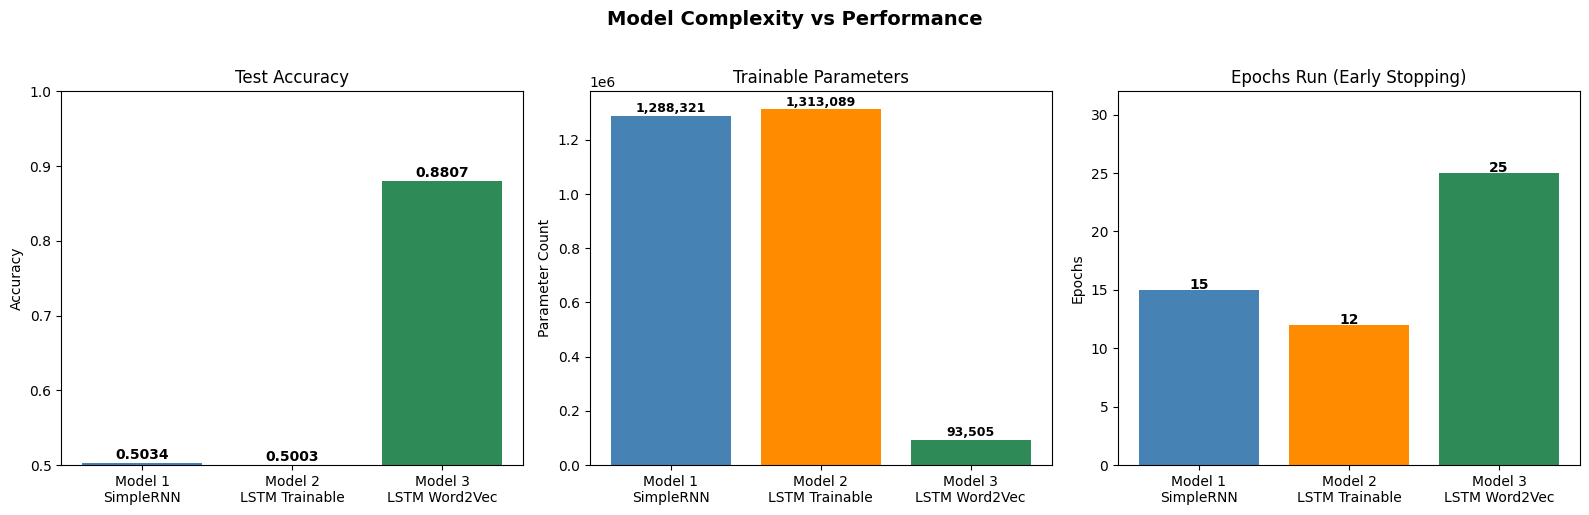

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_labels = ['Model 1\nSimpleRNN', 'Model 2\nLSTM Trainable', 'Model 3\nLSTM Word2Vec']
colors = ['steelblue', 'darkorange', 'seagreen']

# Plot 1 — Test Accuracy
axes[0].bar(model_labels, complexity_df['Test Accuracy'], color=colors)
axes[0].set_title('Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(complexity_df['Test Accuracy']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 2 — Total Trainable Parameters
axes[1].bar(model_labels, complexity_df['Trainable Params'], color=colors)
axes[1].set_title('Trainable Parameters')
axes[1].set_ylabel('Parameter Count')
for i, v in enumerate(complexity_df['Trainable Params']):
    axes[1].text(i, v + complexity_df['Trainable Params'].max() * 0.01,
                 f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Plot 3 — Epochs Run (early stopping)
axes[2].bar(model_labels, complexity_df['Epochs Run'], color=colors)
axes[2].set_title('Epochs Run (Early Stopping)')
axes[2].set_ylabel('Epochs')
axes[2].set_ylim(0, EPOCHS + 2)
for i, v in enumerate(complexity_df['Epochs Run']):
    axes[2].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.suptitle('Model Complexity vs Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Efficiency Score (Accuracy per 1000 Parameters)


Efficiency Score (Accuracy per 1,000 Trainable Parameters):
Higher score = better accuracy relative to model size

                  Model  Trainable Params  Test Accuracy  Efficiency (Acc/1k Params)
     Model 1: SimpleRNN           1288321         0.5034                    0.000391
Model 2: LSTM Trainable           1313089         0.5003                    0.000381
 Model 3: LSTM Word2Vec             93505         0.8807                    0.009419


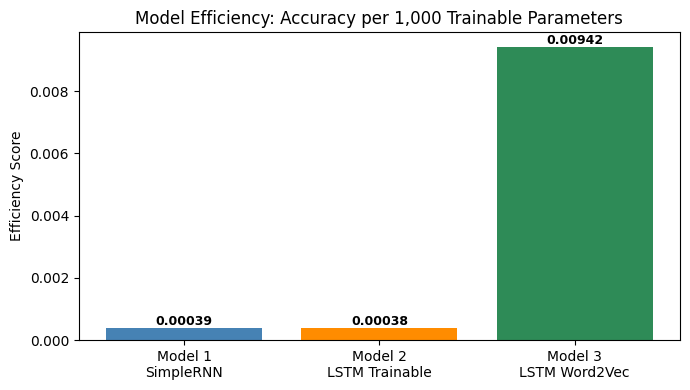

In [ ]:
# Accuracy per 1000 trainable parameters — higher = more efficient
complexity_df['Efficiency (Acc/1k Params)'] = (
    complexity_df['Test Accuracy'] / (complexity_df['Trainable Params'] / 1000)
).round(6)

print("\nEfficiency Score (Accuracy per 1,000 Trainable Parameters):")
print("Higher score = better accuracy relative to model size\n")
print(complexity_df[['Model', 'Trainable Params', 'Test Accuracy',
                      'Efficiency (Acc/1k Params)']].to_string(index=False))

# Bar chart
plt.figure(figsize=(7, 4))
plt.bar(model_labels, complexity_df['Efficiency (Acc/1k Params)'], color=colors)
plt.title('Model Efficiency: Accuracy per 1,000 Trainable Parameters')
plt.ylabel('Efficiency Score')
for i, v in enumerate(complexity_df['Efficiency (Acc/1k Params)']):
    plt.text(i, v + complexity_df['Efficiency (Acc/1k Params)'].max() * 0.01,
             f'{v:.5f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

GUI

In [ ]:

import gradio as gr
import numpy as np
import re
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ── Re-use the same clean_text function from the notebook ──────────────────
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
negation_words = {
    'no', 'not', 'nor', 'never', 'neither', 'nobody', 'nothing',
    'nowhere', 'hardly', 'barely', 'scarcely'
}
stop_words = stop_words - negation_words

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = contractions.fix(text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)


def predict_sentiment(tweet_text, selected_model):
    """
    Takes raw tweet text and a model choice, returns sentiment + confidence.
    Relies on tokenizer, MAX_LEN, model1, model2, model3 from the notebook scope.
    """
    if not tweet_text.strip():
        return "⚠️ Please enter a tweet.", "", ""

    # Map selection to model object
    model_map = {
        "Model 1 – SimpleRNN":          model1,
        "Model 2 – LSTM (Trainable)":   model2,
        "Model 3 – LSTM (GloVe)":       model3,
    }
    model = model_map[selected_model]

    # Preprocess
    cleaned = clean_text(tweet_text)
    if not cleaned:
        return "⚠️ Tweet is empty after cleaning.", "", ""

    # Tokenize & pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict
    prob = float(model.predict(padded, verbose=0)[0][0])
    label = "😊 Positive" if prob >= 0.5 else "😞 Negative"
    confidence = prob if prob >= 0.5 else 1 - prob

    # Confidence bar (simple text visualization)
    bar_filled = int(confidence * 20)
    bar = "█" * bar_filled + "░" * (20 - bar_filled)
    conf_str = f"[{bar}] {confidence * 100:.1f}%"

    return label, conf_str, f'"{cleaned}"'


# ── Gradio UI ───────────────────────────────────────────────────────────────
with gr.Blocks(
    title="Tweet Sentiment Analyser",
    theme=gr.themes.Soft(
        primary_hue="blue",
        secondary_hue="slate",
        font=gr.themes.GoogleFont("IBM Plex Mono"),
    ),
    css="""
    #title  { text-align: center; font-size: 2rem; font-weight: 700; margin-bottom: 0.25rem; }
    #sub    { text-align: center; color: #64748b; margin-bottom: 1.5rem; }
    #label  { font-size: 1.6rem; font-weight: 700; text-align: center; padding: 1rem; }
    #conf   { font-family: monospace; font-size: 0.95rem; }
    #cleaned{ font-style: italic; color: #475569; font-size: 0.85rem; }
    .model-note { font-size: 0.78rem; color: #94a3b8; margin-top: 0.3rem; }
    """
) as demo:

    # Header
    gr.HTML('<div id="title">🐦 Tweet Sentiment Analyser</div>')
    gr.HTML('<div id="sub">Real-time sentiment prediction using RNN / LSTM models</div>')

    with gr.Row():
        with gr.Column(scale=3):
            tweet_input = gr.Textbox(
                label="Enter a Tweet",
                placeholder='e.g. "This movie was absolutely brilliant, can\'t stop thinking about it!"',
                lines=4,
            )
            model_choice = gr.Radio(
                choices=[
                    "Model 1 – SimpleRNN",
                    "Model 2 – LSTM (Trainable)",
                    "Model 3 – LSTM (GloVe)",
                ],
                value="Model 2 – LSTM (Trainable)",
                label="Select Model",
            )
            gr.HTML(
                '<div class="model-note">'
                '⚡ Model 2 is recommended — best accuracy with trainable embeddings.<br>'
                '🧪 Model 3 uses frozen GloVe-50 pretrained vectors.<br>'
                '⚠️  Model 1 (SimpleRNN) may underperform on long sequences.'
                '</div>'
            )
            predict_btn = gr.Button("🔍 Analyse Sentiment", variant="primary", size="lg")

        with gr.Column(scale=2):
            sentiment_out = gr.Textbox(label="Sentiment", elem_id="label", interactive=False)
            confidence_out = gr.Textbox(label="Confidence", elem_id="conf", interactive=False)
            cleaned_out = gr.Textbox(
                label="Cleaned text (what the model sees)",
                elem_id="cleaned",
                interactive=False,
                lines=2,
            )

    # Examples
    gr.Examples(
        examples=[
            ["This product is absolutely amazing, I love it so much!", "Model 2 – LSTM (Trainable)"],
            ["Worst experience of my life. Never buying this again.", "Model 2 – LSTM (Trainable)"],
            ["I don't think this movie was great at all.", "Model 3 – LSTM (GloVe)"],
            ["@user check out this amazing new restaurant! #foodie", "Model 1 – SimpleRNN"],
            ["The service was ok I guess, nothing special tbh.", "Model 2 – LSTM (Trainable)"],
        ],
        inputs=[tweet_input, model_choice],
        label="Try these examples ↓",
    )

    # Footer
    gr.HTML(
        '<div style="text-align:center;color:#94a3b8;font-size:0.78rem;margin-top:1rem;">'
        '6CS012 Final Portfolio Project 2026 · Models trained on IMDB/Twitter sentiment data'
        '</div>'
    )

    # Wire up the button
    predict_btn.click(
        fn=predict_sentiment,
        inputs=[tweet_input, model_choice],
        outputs=[sentiment_out, confidence_out, cleaned_out],
    )

# ── Launch ──────────────────────────────────────────────────────────────────
# share=True gives a public link usable inside Google Colab
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cc508d153166922ef3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Possible reasons for error

1. Sarcasm and irony: A model is not capable of detecting the sarcasm and figurative languages. A tweet like "Oh great, another Monday" uses a set of positive words but it carries the negative meaning. Even though the sentence clearly denotes the negative sentiment , the model misclassifies it as a positive sentiment.

2. Negation: The model does not fully handle the complex negation patterns. For instance, "not bad at all" is a positive remark but the word "bad" can pull the negative prediction.

3. Context and word order: Simple RNN and basic LSSTM treat the word sequences in a linear pattern. They can miss long-range dependencies — where a word at the start of a tweet changes the meaning of something said at the end.

4. Model 1 vanishing gradient: Simple RNN can not remember the long sentences due to the vanishing gradient problem, so it misses sentiment cues that appear early in a tweet and are relevant to the ending.

5. Confusing Tweets: A minimal tweet such as "ok" or "interesting" offers insufficient clues for the model. Such tweets typically occur in close proximity to the 0.5 threshold point and oscillate between sentiments.

Suggest potential improvements

1. Bidirectional LSTM: A standard LSTM only reads the sequence left-to-right, so it misses context that comes after a word. A Bidirectional(LSTM(...)) wrapper reads the sequence in both directions and concatenates the hidden states, which helps especially with negation and sentiment modifiers mid-sentence.

2. Dropout to Reduce Overfitting: The models have not used regularization. By adding the dropout mainly in model 2 which has the most trainable parameters, it could use to reduce the overfitting.

3. Stack Multiple LSTM Layers: A single LSTM layer captures only one level of sequential abstraction. Stacking two LSTM layers (setting return_sequences=True on the first) allows the model to learn hierarchical patterns, word-level patterns feeding into phrase-level patterns.

4. Attention Mechanism: Not every word in a tweet contributes equally to the sentiment. An attention layer lets the model learn to weight important words (like "terrible" or "love") more heavily than filler words. This is especially useful for longer tweets where key sentiment words may appear at any position.

In [ ]:
import time
import os
import psutil
import subprocess

def get_gpu_info():
    try:
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,memory.total,memory.used,memory.free,utilization.gpu',
             '--format=csv,noheader,nounits'],
            capture_output=True, text=True
        )
        lines = result.stdout.strip().split('\n')
        for line in lines:
            name, mem_total, mem_used, mem_free, util = line.split(',')
            print(f"  GPU Name        : {name.strip()}")
            print(f"  Total Memory    : {int(mem_total):,} MB")
            print(f"  Used Memory     : {int(mem_used):,} MB")
            print(f"  Free Memory     : {int(mem_free):,} MB")
            print(f"  GPU Utilization : {util.strip()}%")
    except Exception as e:
        print(f"  GPU info unavailable: {e}")

def get_ram_usage():
    mem = psutil.virtual_memory()
    print(f"  RAM Used        : {mem.used / 1024**3:.2f} GB")
    print(f"  RAM Available   : {mem.available / 1024**3:.2f} GB")
    print(f"  RAM Total       : {mem.total / 1024**3:.2f} GB")

print("=" * 50)

print("=" * 50)
get_gpu_info()
get_ram_usage()

  GPU Name        : Tesla T4
  Total Memory    : 15,360 MB
  Used Memory     : 645 MB
  Free Memory     : 14,268 MB
  GPU Utilization : 0%
  RAM Used        : 6.85 GB
  RAM Available   : 5.48 GB
  RAM Total       : 12.67 GB
